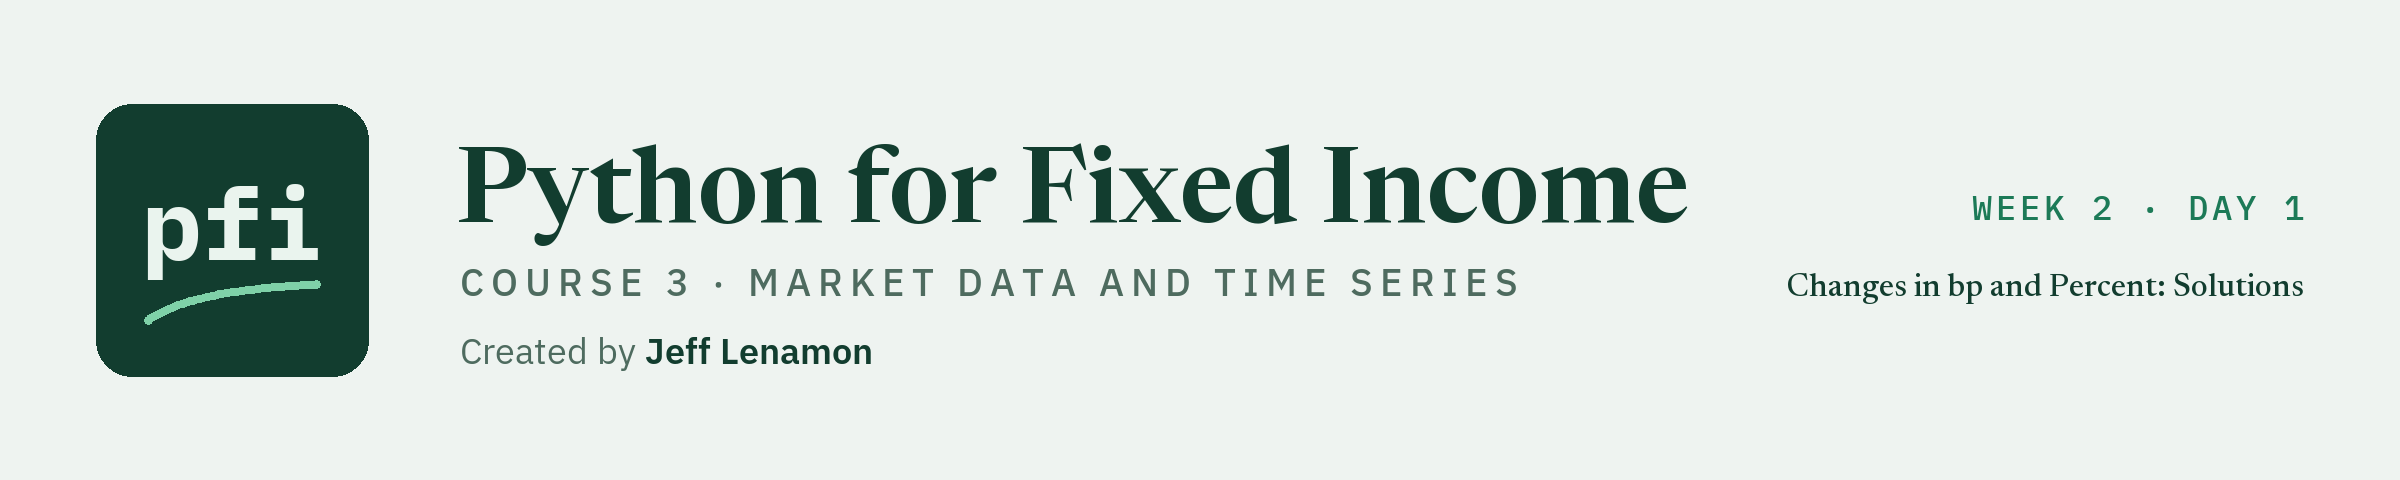

# Changes in bp and Percent: Solutions

Week 2, Day 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week2/day1/06_changes_in_bp_and_percent_solutions.ipynb)

This notebook stands on its own. Its setup writes `marketdata.py` and `test_marketdata.py` as they stand at the end of today, so the exercises can be run without the lesson. It needs no key.

Q. Set up today's work folder.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_06_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_excel_reference.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_06_kmlmdaxi, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_excel_reference.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the end of today.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series


def change_bp(series: pd.Series, periods: int = 1, percent_units: bool = True) -> pd.Series:
    """Change over `periods` observations, in basis points.

    Units: the result is in bp. percent_units=True for a series in percent (a yield): (x_t - x_{t-k}) x 100.
    percent_units=False for a series already in bp (a spread): x_t - x_{t-k}.
    Convention: k rows back, whatever the calendar gap (the Tuesday after a Monday holiday is a change from
    Friday). The first `periods` values are NaN. Never a percent change of a yield or spread level.
    Excel: =(B3-B2)*100 for a yield in percent.
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # the difference from k rows back
    difference = series - series.shift(periods)
    # percent to basis points: 1 percent is 100 bp
    return difference * 100 if percent_units else difference


def return_pct(series: pd.Series, periods: int = 1) -> pd.Series:
    """Simple return over `periods` observations, in percent, for a price series.

    Units: prices in, percent out. Convention: (P_t / P_{t-k} - 1) x 100, k rows back; no log returns.
    The first `periods` values are NaN. Excel: =(C3/C2-1)*100
    Raises ValueError if periods is below 1, the series has missing values, or its index is not unique
    ascending dates.
    """
    _check_series(series, "series")
    if periods < 1:
        raise ValueError(f"periods must be at least 1, not {periods}")
    # price now over price k rows back, less one, in percent
    return (series / series.shift(periods) - 1) * 100


def change_since_bp(series: pd.Series, as_of, since, percent_units: bool = True) -> float:
    """Change from the as-of value at `since` to the as-of value at `as_of`, in basis points.

    Units: the result is in bp; percent_units as change_bp. Convention: each end is the last observation
    on or before its date (value_as_of), so a `since` on a holiday or weekend uses the market day before it.
    One week back is as_of - 7 days; one month back is as_of - pd.DateOffset(months=1).
    Excel: =(XLOOKUP(as_of,A:A,B:B,,-1)-XLOOKUP(since,A:A,B:B,,-1))*100
    Raises ValueError if since is after as_of or before the first observation.
    """
    if pd.Timestamp(since) > pd.Timestamp(as_of):
        raise ValueError(f"since ({pd.Timestamp(since).date()}) must not be after as_of ({pd.Timestamp(as_of).date()})")
    # the as-of value at each end
    _, value_now = value_as_of(series, as_of)
    _, value_then = value_as_of(series, since)
    difference = value_now - value_then
    return difference * 100 if percent_units else difference

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")


def test_cache_round_trip_exact(tmp_path):
    # the FRED-format sample, "." row and all, through the cache and back
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    path = md.write_cache(series, tmp_path / "cache")
    assert path.name == "DGS10.csv"
    back = md.read_cache("DGS10", tmp_path / "cache")
    pd.testing.assert_series_equal(back, series, check_exact=True)
    # numbers with more digits than two also come back bit for bit
    awkward = (series.dropna() / 3).rename("THIRDS")
    md.write_cache(awkward, tmp_path / "cache")
    pd.testing.assert_series_equal(md.read_cache("THIRDS", tmp_path / "cache"), awkward, check_exact=True)


def test_read_cache_missing_raises(tmp_path):
    with pytest.raises(FileNotFoundError):
        md.read_cache("DGS10", tmp_path)


def test_licensed_series_not_cached(monkeypatch, tmp_path):
    # any attempt to reach the network fails the test
    def no_network(*args, **kwargs):
        raise AssertionError("cached_fred_series must not send a request for a licensed series")

    monkeypatch.setattr(requests, "get", no_network)
    for series_id in ("BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"):
        with pytest.raises(ValueError, match="licensed"):
            md.cached_fred_series(series_id, FAKE_KEY, tmp_path / "cache")
    # nothing was written
    assert not (tmp_path / "cache").exists()


def read_reference() -> pd.DataFrame:
    """The Excel reference rows in this folder: one per 2026 market date, every value computed by Excel."""
    return pd.read_csv(HERE / "course3_excel_reference.csv", parse_dates=["date"], index_col="date",
                       float_precision="round_trip")


def test_change_bp_hand_series():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    yields = pd.Series([4.00, 4.10, 4.05], index=dates)
    changes = md.change_bp(yields)
    # 4.00 to 4.10 is 10 bp; the Tuesday after Labor Day is a change from Friday
    assert math.isnan(changes.iloc[0])
    assert changes.iloc[1] == pytest.approx(10.0, abs=1e-9)
    assert changes.loc["2026-09-08"] == pytest.approx(-5.0, abs=1e-9)
    assert md.change_bp(yields, periods=2).iloc[2] == pytest.approx(5.0, abs=1e-9)


def test_change_bp_spread_units():
    spreads = pd.Series([98.8, 101.3], index=pd.to_datetime(["2026-09-29", "2026-09-30"]))
    # a spread is already in bp, so nothing is multiplied
    assert md.change_bp(spreads, percent_units=False).iloc[1] == pytest.approx(2.5, abs=1e-9)


def test_return_pct_hand_series():
    prices = pd.Series([100.0, 101.0, 99.99], index=pd.to_datetime(["2026-09-28", "2026-09-29", "2026-09-30"]))
    returns = md.return_pct(prices)
    assert returns.iloc[1] == pytest.approx(1.0, abs=1e-12)
    assert returns.iloc[2] == pytest.approx(-1.0, abs=1e-12)


def test_change_since_uses_as_of_values():
    ten = read_treasury()["10 Yr"]
    # since Labor Day 2026-09-07 (no row) means since Friday 2026-09-04
    expected = (ten.loc["2026-09-30"] - ten.loc["2026-09-04"]) * 100
    assert md.change_since_bp(ten, "2026-09-30", "2026-09-07") == pytest.approx(expected, abs=1e-9)
    with pytest.raises(ValueError):
        md.change_since_bp(ten, "2026-09-07", "2026-09-30")


def test_change_bp_matches_excel_reference():
    reference = read_reference()
    ten = read_treasury()["10 Yr"]
    changes = md.change_bp(ten)
    for day, row in reference.iterrows():
        # Excel: =(D_t-D_t-1)*100, filled down
        assert changes.loc[day] == pytest.approx(row["chg_10y_bp"], abs=1e-9), day
        # the one-month as-of change: =(D_t-XLOOKUP(EDATE(A_t,-1),...,-1))*100
        month_back = day - pd.DateOffset(months=1)
        assert md.change_since_bp(ten, day, month_back) == pytest.approx(row["chg1m_10y_bp"], abs=1e-9), day

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs', '_check_series', 'last_per_period', 'value_as_of', 'write_cache', 'read_cache', 'cached_fred_series', 'change_bp', 'return_pct', 'change_since_bp']


## Exercises

Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the Treasury file, the synthetic spreads, and Excel's reference rows, and defines `check`, a small function that marks your answers.

In [6]:
treasury = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
reference = pd.read_csv("course3_excel_reference.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Weekly changes in the 2 Yr. Take the last observation of each week ending Friday with `md.last_per_period(..., "W-FRI")`, then the change from one week's row to the next with `md.change_bp`. Keep the weeks that end in September 2026. Store how many there are in **ex1_count** and the largest weekly change, in bp, in **ex1_largest**.

In [7]:
# the last observation of each week, labelled by its own date
weekly = md.last_per_period(treasury["2 Yr"], "W-FRI")
# one row back is one week back
weekly_changes = md.change_bp(weekly)
september = weekly_changes.loc["2026-09"]
print(september.round(1).to_string())

ex1_count = len(september)
ex1_largest = september.max()

date
2026-09-04     3.0
2026-09-11    26.0
2026-09-18    13.0
2026-09-25     5.0


* 4 weeks end in September 2026. The largest weekly rise was 26 bp, in the week ending 2026-09-11. Each row is a change from the previous week's last observation, so the week of Labor Day still compares Friday with Friday.

In [8]:
check("Exercise 1 the number of weeks", ex1_count, 4)
check("Exercise 1 the largest weekly change", ex1_largest, 25.99999999999998)

Exercise 1 the number of weeks: correct
Exercise 1 the largest weekly change: correct


### Exercise 2

Q. Month-to-date changes in the synthetic spreads, as of 2026-10-02. Month to date means since the last day of the previous month: compute that date from `as_of` (hint: the first of the month, less one day). Use `md.change_since_bp`, and remember the spreads are in bp. Store the investment grade change in **ex2_ig** and the high yield change in **ex2_hy**.

In [9]:
as_of = pd.Timestamp("2026-10-02")
# the last day of the previous month: the first of this month, less one day
since = as_of.replace(day=1) - pd.Timedelta(days=1)

ex2_ig = md.change_since_bp(spreads["ig_spread_bp"], as_of, since, percent_units=False)
ex2_hy = md.change_since_bp(spreads["hy_spread_bp"], as_of, since, percent_units=False)
print(f"since {since.date()}: IG {ex2_ig:+.1f} bp, HY {ex2_hy:+.1f} bp (synthetic)")

since 2026-09-30: IG -1.8 bp, HY -6.0 bp (synthetic)


* Since 2026-09-30: -1.8 bp for investment grade and -6.0 bp for high yield. Had the last day of September not been a market day, the as-of value would have stepped back to the last one that was, with no change to the code.

In [10]:
check("Exercise 2 investment grade, month to date", ex2_ig, -1.7999999999999972)
check("Exercise 2 high yield, month to date", ex2_hy, -6.0)

Exercise 2 investment grade, month to date: correct
Exercise 2 high yield, month to date: correct


### Exercise 3

Q. Add a function to your module. `yield_change_table(curve, tenors, as_of)` returns a DataFrame with one row per tenor and four columns: `level_pct` (the as-of value), `chg_1d_bp` (the change from the observation before the as-of row), `chg_1w_bp`, and `chg_1m_bp` (as-of values 7 days and one month back). Drop each tenor's missing values first. Write the docstring first. Inside the module, call `value_as_of` and `change_since_bp` without the `md.` prefix: they are in the same file. Then add a test, `test_yield_change_table_known_date`, that checks the 2 Yr and 10 Yr on 2026-10-02: the index, the 10 Yr level 5.28, the 1-day change against `md.change_bp`, and the 1-month change against Excel's reference row (`read_reference()` is already in the test file). Run pytest, reload the module, and store `md.yield_change_table(treasury, ["2 Yr", "5 Yr", "10 Yr", "30 Yr"], "2026-10-02").loc["30 Yr", "chg_1m_bp"]` in **ex3_value**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [11]:
%%writefile -a marketdata.py


def yield_change_table(curve: pd.DataFrame, tenors: list[str], as_of) -> pd.DataFrame:
    """One row per tenor: the level and the 1-day, 1-week, and 1-month changes, all as of one date.

    Units: level_pct in percent (the curve's units); the three changes in bp. Convention: the level is the
    as-of value; the 1-day change is from the observation before the as-of row; the 1-week and 1-month
    changes use as-of values 7 calendar days and one calendar month back (change_since_bp). Each tenor's
    missing values are dropped first, so a tenor that starts late still works after its start.
    Raises ValueError if as_of is before a tenor's first observation.
    """
    as_of = pd.Timestamp(as_of)
    rows = {}
    for tenor in tenors:
        series = curve[tenor].dropna()
        # the as-of row and the row before it
        used, level = value_as_of(series, as_of)
        previous = series.index[series.index.get_loc(used) - 1]
        rows[tenor] = {
            "level_pct": level,
            "chg_1d_bp": change_since_bp(series, used, previous),
            "chg_1w_bp": change_since_bp(series, as_of, as_of - pd.Timedelta(days=7)),
            "chg_1m_bp": change_since_bp(series, as_of, as_of - pd.DateOffset(months=1)),
        }
    return pd.DataFrame.from_dict(rows, orient="index")

Appending to marketdata.py


In [12]:
%%writefile -a test_marketdata.py


def test_yield_change_table_known_date():
    curve = read_treasury()
    table = md.yield_change_table(curve, ["2 Yr", "10 Yr"], "2026-10-02")
    assert list(table.index) == ["2 Yr", "10 Yr"]
    assert table.loc["10 Yr", "level_pct"] == 5.28
    # the 1-day change is the last row of change_bp, the 1-month change Excel's reference value
    assert table.loc["10 Yr", "chg_1d_bp"] == pytest.approx(md.change_bp(curve["10 Yr"]).iloc[-1], abs=1e-9)
    assert table.loc["10 Yr", "chg_1m_bp"] == pytest.approx(read_reference().loc["2026-10-02", "chg1m_10y_bp"], abs=1e-9)

Appending to test_marketdata.py


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........................                                               [100%]
26 passed in 1.07s



In [14]:
# the file changed, so reload before calling the new function
importlib.reload(md)

table = md.yield_change_table(treasury, ["2 Yr", "5 Yr", "10 Yr", "30 Yr"], "2026-10-02")
ex3_value = table.loc["30 Yr", "chg_1m_bp"]
table.round(2)

,level_pct,chg_1d_bp,chg_1w_bp,chg_1m_bp
2 Yr,4.83,5.0,2.0,44.0
5 Yr,5.06,5.0,8.0,52.0
10 Yr,5.28,4.0,11.0,49.0
30 Yr,5.63,2.0,14.0,36.0


* `26 passed`: the 25 from the lesson and the new one.
* One row per tenor, every change in bp, every number as of one date: the top of a morning note. Day 10's `summary_table` grows this into the full set of measures.

In [15]:
check("Exercise 3 the 30 Yr one-month change", ex3_value, 36.00000000000003)

Exercise 3 the 30 Yr one-month change: correct


### Exercise 4: AI check

You ask an AI assistant for a function that returns the daily change of a yield series in bp, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Daily change of a yield series, in basis points.

    Units: yields in percent in, bp out: (y_t - y_{t-1}) x 100, from the previous observation (row),
    whatever the calendar gap. The first value is NaN. Never a percent change of the yield level.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

* The bug: `pct_change()` is the percent change of the level, (y_t / y_t-1 - 1), so times 100 it is a percent change of the yield, labelled bp. On 2026-10-02 it returns 0.7634 for a 4 bp move. It runs, it returns small plausible numbers, and the docstring's last sentence forbids exactly this.
* The fix, in the cell below: the difference from the previous row, times 100.

In [16]:
def daily_change_bp(series):
    """Daily change of a yield series, in basis points.

    Units: yields in percent in, bp out: (y_t - y_{t-1}) x 100, from the previous observation (row),
    whatever the calendar gap. The first value is NaN. Never a percent change of the yield level.
    """
    # the fix: the difference from the previous row, times 100 (1 percent is 100 bp), as =(B3-B2)*100
    return (series - series.shift(1)) * 100

In [17]:
# the test, written from the docstring before the code is trusted: Excel's =(B3-B2)*100 on the 190 rows of 2026
ai_changes = daily_change_bp(treasury["10 Yr"]).loc[reference.index]
ai_gap = (ai_changes - reference["chg_10y_bp"]).abs().max()
assert ai_gap <= 1e-9, f"differs from Excel's daily change in bp by up to {ai_gap:.2f} bp"
print(f"Equal to Excel on all {len(reference)} rows of 2026: largest gap {ai_gap:.1e} bp")

Equal to Excel on all 190 rows of 2026: largest gap 0.0e+00 bp


In [18]:
ex4_last = daily_change_bp(treasury["10 Yr"]).iloc[-1]
print(f"last day: {ex4_last:+.1f} bp")

last day: +4.0 bp


* The fixed function returns 4 bp for the last day and matches Excel on every row of 2026. Keep the test in your test file; the bug cannot come back unnoticed.

In [19]:
check("Exercise 4 the last daily change", ex4_last, 4.0000000000000036)

Exercise 4 the last daily change: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```